In [9]:
import pandas as pd
import numpy as np
from io import BytesIO, StringIO
import torch
import joblib
import boto3
import os
from dotenv import load_dotenv
import json
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
from datetime import datetime

In [12]:
# This cell downloads the SBERT model directory, embeddings, and job descriptions from S3 (S3-only).
# It performs explicit checks so failures are informative.
load_dotenv()

bucket_name = os.getenv('S3_BUCKET_NAME', 'resume-matcher-bucket-sahil')
model_dir_key = os.getenv('MODEL_S3_KEY', 'models/sbert_model/')
embeddings_key = os.getenv('EMBEDDINGS_S3_KEY', 'models/job_embeddings.pt')
job_desc_key = os.getenv('JOB_DATA_S3_KEY', 'raw-data/job_title_des.csv')
local_model_path = 'sbert_model_from_s3'

s3 = boto3.client(
    's3',
    aws_access_key_id=os.getenv('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('AWS_SECRET_ACCESS_KEY'),
)

s3_resource = boto3.resource('s3')
print('='*60)
print('LOADING MODEL AND EMBEDDINGS FROM S3 (S3-only)')
print('Bucket:', bucket_name)
print('Model prefix:', model_dir_key)
print('Embeddings key:', embeddings_key)
print('Job descriptions key:', job_desc_key)
print('='*60)

# Ensure local folder exists
if not os.path.exists(local_model_path):
    os.makedirs(local_model_path, exist_ok=True)

# 1) Download model directory from S3
bucket = s3_resource.Bucket(bucket_name)
objects = list(bucket.objects.filter(Prefix=model_dir_key))
if not objects:
    raise FileNotFoundError(f"No objects found at s3://{bucket_name}/{model_dir_key}. Check the MODEL_S3_KEY and bucket.")

print(f"Found {len(objects)} objects under prefix {model_dir_key}. Downloading...")
for obj in objects:
    if obj.key.endswith('/'):
        # skip folder markers
        continue
    rel_path = os.path.relpath(obj.key, model_dir_key)
    target_path = os.path.join(local_model_path, rel_path)
    target_dir = os.path.dirname(target_path)
    if target_dir and not os.path.exists(target_dir):
        os.makedirs(target_dir, exist_ok=True)
    print(f"Downloading s3://{bucket_name}/{obj.key} -> {target_path}")
    try:
        bucket.download_file(obj.key, target_path)
    except Exception as e:
        print(f"Failed to download {obj.key}: {e}")
        raise

# List downloaded files for debugging
print('\nDownloaded model files:')
all_downloaded_files = []
for root, dirs, files in os.walk(local_model_path):
    for f in files:
        path = os.path.join(root, f)
        all_downloaded_files.append(path)
        print(path)

# Check for expected model weight files
weight_names = ['pytorch_model.bin', 'model.safetensors', 'tf_model.h5', 'model.ckpt.index', 'flax_model.msgpack']
found_weight = any(any(p.endswith(w) for w in weight_names) for p in all_downloaded_files)
if not found_weight:
    raise OSError(
        f"No recognized model weight file found in {local_model_path}. Expected one of: {weight_names}.\n"
        f"Downloaded files: {all_downloaded_files}\n"
        "Make sure the S3 model directory actually contains the transformer weights."
    )

# Load SentenceTransformer from the downloaded local directory
print('\nLoading SentenceTransformer from local path...')
model = SentenceTransformer(local_model_path)
print('✅ SBERT Model loaded successfully')

# 2) Load pre-computed job embeddings from S3
print('\nDownloading job embeddings from S3...')
embeddings_buffer = BytesIO()
try:
    s3.download_fileobj(Bucket=bucket_name, Key=embeddings_key, Fileobj=embeddings_buffer)
    embeddings_buffer.seek(0)
    job_embeddings = torch.load(embeddings_buffer)
    print(f"✅ Job embeddings loaded successfully: {job_embeddings.shape}")
except Exception as e:
    raise FileNotFoundError(f"Could not download/parse embeddings from s3://{bucket_name}/{embeddings_key}: {e}")

# 3) Load job descriptions for mapping results from S3
print('\nDownloading job descriptions CSV from S3...')
try:
    job_desc_obj = s3.get_object(Bucket=bucket_name, Key=job_desc_key)
    df_job_description = pd.read_csv(StringIO(job_desc_obj['Body'].read().decode('utf-8')))
    print(f"✅ Job descriptions data loaded ({len(df_job_description)} rows)")
except Exception as e:
    raise FileNotFoundError(f"Could not fetch job descriptions from s3://{bucket_name}/{job_desc_key}: {e}")


LOADING MODEL AND EMBEDDINGS FROM S3 (S3-only)
Bucket: resume-matcher-bucket-sahil
Model prefix: models/sbert_model/
Embeddings key: models/job_embeddings.pt
Job descriptions key: raw-data/job_title_des.csv
Found 11 objects under prefix models/sbert_model/. Downloading...
Found 11 objects under prefix models/sbert_model/. Downloading...

Downloaded model files:
sbert_model_from_s3\config.json
sbert_model_from_s3\config_sentence_transformers.json
sbert_model_from_s3\model.safetensors
sbert_model_from_s3\modules.json
sbert_model_from_s3\README.md
sbert_model_from_s3\sentence_bert_config.json
sbert_model_from_s3\special_tokens_map.json
sbert_model_from_s3\tokenizer.json
sbert_model_from_s3\tokenizer_config.json
sbert_model_from_s3\vocab.txt
sbert_model_from_s3\1_Pooling\config.json

Loading SentenceTransformer from local path...

Downloaded model files:
sbert_model_from_s3\config.json
sbert_model_from_s3\config_sentence_transformers.json
sbert_model_from_s3\model.safetensors
sbert_model_f

In [14]:
# --- Step 2: Define a new resume for matching ---
new_resume_text = """
Experienced data scientist with a background in machine learning, Python, and SQL.
Proven track record of building and deploying predictive models in a cloud environment.
Skilled in data visualization and statistical analysis.
"""

print("New resume to match:")
print(new_resume_text)

# --- Step 3: Perform the Matching (Prediction) ---
print('\n' + '='*60)
print('PERFORMING RESUME-JOB MATCHING')
print('='*60)

# 1. Generate embedding for the new resume
resume_embedding = model.encode(new_resume_text, convert_to_tensor=True)
print("✅ New resume embedding generated")

# 2. Compute cosine similarity
cos_scores = util.cos_sim(resume_embedding, job_embeddings)[0]
print("✅ Cosine similarity computed against all job descriptions")

# 3. Get top N matches
top_n = 5
top_results = torch.topk(cos_scores, k=top_n)

print(f"\nTop {top_n} Job Matches:")
results = []
for i, (score, idx) in enumerate(zip(top_results[0], top_results[1])):
    # idx is a torch scalar tensor - convert to Python int for pandas indexing
    idx_int = int(idx.item()) if hasattr(idx, 'item') else int(idx)
    job_title = df_job_description.iloc[idx_int]['Job Title']
    similarity = float(score.item()) if hasattr(score, 'item') else float(score)
    print(f"{i+1}. {job_title:35} --> Similarity: {similarity:.4f}")
    results.append({'rank': i+1, 'job_title': job_title, 'similarity_score': similarity})

df_results = pd.DataFrame(results)

New resume to match:

Experienced data scientist with a background in machine learning, Python, and SQL.
Proven track record of building and deploying predictive models in a cloud environment.
Skilled in data visualization and statistical analysis.


PERFORMING RESUME-JOB MATCHING
✅ New resume embedding generated
✅ Cosine similarity computed against all job descriptions

Top 5 Job Matches:
1. Machine Learning                    --> Similarity: 0.7375
2. Machine Learning                    --> Similarity: 0.7223
3. Machine Learning                    --> Similarity: 0.7130
4. Machine Learning                    --> Similarity: 0.7110
5. Machine Learning                    --> Similarity: 0.6930


In [15]:
# --- Step 4: Save Prediction Results to S3 ---
print('\n' + '='*60)
print('SAVING MATCHING RESULTS TO S3')
print('='*60)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_key = f'predictions/matching_results_{timestamp}.csv'

results_buffer = StringIO()
df_results.to_csv(results_buffer, index=False)
results_buffer.seek(0)
s3.put_object(Bucket=bucket_name, Key=results_key, Body=results_buffer.getvalue())
print(f"Matching results saved to: s3://{bucket_name}/{results_key}")


SAVING MATCHING RESULTS TO S3
Matching results saved to: s3://resume-matcher-bucket-sahil/predictions/matching_results_20251103_033953.csv
Matching results saved to: s3://resume-matcher-bucket-sahil/predictions/matching_results_20251103_033953.csv



GENERATING AND SAVING VISUALIZATION
✅ Visualization uploaded to S3: s3://resume-matcher-bucket-sahil/predictions/matching_visualization_20251103_033953.png
✅ Visualization uploaded to S3: s3://resume-matcher-bucket-sahil/predictions/matching_visualization_20251103_033953.png


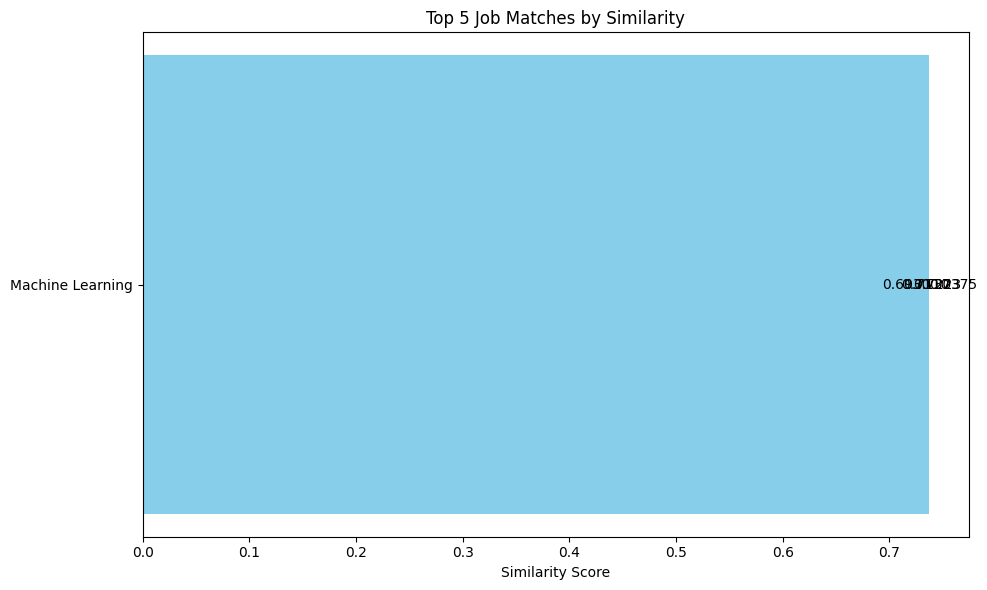

In [16]:
# --- Step 5: Visualize and Save Plot to S3 ---
print('\n' + '='*60)
print('GENERATING AND SAVING VISUALIZATION')
print('='*60)

plt.figure(figsize=(10, 6))
bars = plt.barh(df_results['job_title'], df_results['similarity_score'], color='skyblue')
plt.xlabel('Similarity Score')
plt.title(f'Top {top_n} Job Matches by Similarity')
plt.gca().invert_yaxis() # Display the highest score at the top
plt.bar_label(bars, fmt='%.4f')
plt.tight_layout()

# Save plot to a buffer
img_buffer = BytesIO()
plt.savefig(img_buffer, format='png')
img_buffer.seek(0)

# Upload plot to S3
plot_key = f'predictions/matching_visualization_{timestamp}.png'
s3.upload_fileobj(img_buffer, bucket_name, plot_key)
print(f"✅ Visualization uploaded to S3: s3://{bucket_name}/{plot_key}")
plt.show()